<a href="https://colab.research.google.com/github/jahnavimidde/Deep_learning/blob/main/DL_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

# ==========================================
# 1. Import Libraries
# ==========================================
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical

# ==========================================
# 2. Load Dataset (FIXED ✅)
# ==========================================
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Reshape to add channel (28x28 → 28x28x1)
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

print("Train shape:", X_train.shape)   # (60000, 28, 28, 1)

# Use subset (for speed ⚡)
X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# ==========================================
# 3. Data Preprocessing
# ==========================================
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# ==========================================
# 4. One-Hot Encoding
# ==========================================
n_classes = 10
Y_train = to_categorical(y_train, n_classes)
Y_test = to_categorical(y_test, n_classes)

# ==========================================
# 5. Build CNN Model (FIXED INPUT SHAPE ✅)
# ==========================================
model = Sequential()

# Conv Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPool2D(pool_size=(2,2)))

# Conv Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output
model.add(Dense(10, activation='softmax'))

# ==========================================
# 6. Compile
# ==========================================
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# ==========================================
# 7. Train
# ==========================================
history = model.fit(
    X_train, Y_train,
    batch_size=16,   # balanced
    epochs=10,
    validation_data=(X_test, Y_test)
)

# ==========================================
# 8. Evaluate
# ==========================================
loss, accuracy = model.evaluate(X_test, Y_test)
print("Test Accuracy:", accuracy)



Train shape: (60000, 28, 28, 1)
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.6977 - loss: 0.8259 - val_accuracy: 0.7850 - val_loss: 0.5338
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8011 - loss: 0.5411 - val_accuracy: 0.8415 - val_loss: 0.4508
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8315 - loss: 0.4703 - val_accuracy: 0.8650 - val_loss: 0.3985
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8487 - loss: 0.4188 - val_accuracy: 0.8695 - val_loss: 0.3919
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8653 - loss: 0.3778 - val_accuracy: 0.8855 - val_loss: 0.3532
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8740 - loss: 0.3481 - val_accuracy: 0.8800 - val_loss: 0.3561
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8826 - loss: 0.3189 - val_accuracy: 0.8775 - val_loss: 0.3479
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - ac

 accuracy 0.8510000109672546    if batch size is 32  and epoch is 5




 if batch size is 16 (epoch is 5)Test Accuracy: 0.8669999837875366


if the epoch size is 10

 Test Accuracy: 0.8784999847412109




 Small Batch Size (like 16)

More updates per epoch
Gradient is noisy (varies more)

Better learning of patterns
Better generalization
Higher accuracy



32 → 85.1%
16 → 86.7%
 Large Batch Size (like 32, 64, 128)

Fewer updates
Gradient is smooth (stable)

Faster training
But may miss important patterns
Lower accuracy



ncreasing epochs from 5 to 10 improved accuracy from 86.7% to 87.8%
More epochs allow the model to learn better representations
Training becomes more refined with additional iterations
 Combined Effect
Best performance observed with:
Batch size = 16
Epochs = 10
Shows that proper tuning improves CNN performance

***Pre trained models***

In [6]:

# ==========================================
# 1. Import Libraries
# ==========================================
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
import tensorflow as tf

# ==========================================
# 2. Load Dataset
# ==========================================
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Reshape to add channel
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# Reduce dataset (for speed ⚡)
X_train = X_train[:10000]
y_train = y_train[:10000]
X_test = X_test[:2000]
y_test = y_test[:2000]

# Normalize
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# Convert grayscale → RGB (required for big models)
X_train_rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(X_train))
X_test_rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(X_test))

# Resize (lighter than 224)
X_train_resized = tf.image.resize(X_train_rgb, (64,64))
X_test_resized = tf.image.resize(X_test_rgb, (64,64))

# One-hot encoding
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# ==========================================
# 3. LeNet
# ==========================================
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense

model_lenet = Sequential()

model_lenet.add(Conv2D(6, (5,5), activation='relu', input_shape=(28,28,1)))
model_lenet.add(MaxPool2D())

model_lenet.add(Conv2D(16, (5,5), activation='relu'))
model_lenet.add(MaxPool2D())

model_lenet.add(Flatten())
model_lenet.add(Dense(120, activation='relu'))
model_lenet.add(Dense(84, activation='relu'))
model_lenet.add(Dense(10, activation='softmax'))

model_lenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_lenet.fit(X_train, Y_train, epochs=10, batch_size=16, validation_data=(X_test, Y_test))
loss, acc = model_lenet.evaluate(X_test, Y_test)
print("LeNet Test Accuracy:", acc)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7054 - loss: 0.7926 - val_accuracy: 0.7785 - val_loss: 0.5790
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8042 - loss: 0.5209 - val_accuracy: 0.8215 - val_loss: 0.5081
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8347 - loss: 0.4462 - val_accuracy: 0.8210 - val_loss: 0.4747
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8586 - loss: 0.3896 - val_accuracy: 0.8580 - val_loss: 0.4173
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8683 - loss: 0.3525 - val_accuracy: 0.8515 - val_loss: 0.4357
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8791 - loss: 0.3297 - val_accuracy: 0.8520 - val_loss: 0.4051
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8868 - loss: 0.3032 - val_accuracy: 0.8635 - val_loss: 0.3936
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8933 - loss: 0.2827 - val_accu

1. LeNet Performance
The model achieved a test accuracy of ~85.15%
Training accuracy steadily increased from 70% → 90%
Validation accuracy peaked around 86.5% (Epoch 8) and then slightly decreased

Observation:

Indicates mild overfitting after Epoch 8
LeNet performs well but is limited due to its shallow architecture

In [19]:
# ==========================================
# 4. AlexNet (Lightweight Version)
# ==========================================
model_alexnet = Sequential()

model_alexnet.add(Conv2D(64, (5,5), strides=1, activation='relu', input_shape=(64,64,3)))
model_alexnet.add(MaxPool2D(pool_size=(2,2)))

model_alexnet.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model_alexnet.add(MaxPool2D(pool_size=(2,2)))

model_alexnet.add(Flatten())
model_alexnet.add(Dense(512, activation='relu'))
model_alexnet.add(Dropout(0.5))
model_alexnet.add(Dense(10, activation='softmax'))

model_alexnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_alexnet.fit(X_train_resized, Y_train, epochs=4, batch_size=16, validation_data=(X_test_resized, Y_test))
loss, acc = model_alexnet.evaluate(X_test_resized, Y_test)
print("AlexNet Test Accuracy:", acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 10000
'y' sizes: 50000


AlexNet Performance
Achieved test accuracy of ~87.95%
Validation accuracy peaked at ~89.05% (Epoch 3)
Slight drop after further training
Observation:

Better than LeNet due to:
Deeper architecture
Better feature extraction
Slight overfitting observed after Epoch 3

 Key Insight:

Early stopping around Epoch 3–4 would give optimal performance

In [7]:
# ==========================================
# 5. ZF-Net (Simplified)
# ==========================================
model_zf = Sequential()

model_zf.add(Conv2D(64, (3,3), activation='relu', input_shape=(64,64,3)))
model_zf.add(MaxPool2D())

model_zf.add(Conv2D(128, (3,3), activation='relu'))
model_zf.add(MaxPool2D())

model_zf.add(Flatten())
model_zf.add(Dense(512, activation='relu'))
model_zf.add(Dropout(0.5))
model_zf.add(Dense(10, activation='softmax'))

model_zf.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_zf.fit(X_train_resized, Y_train, epochs=5, batch_size=16, validation_data=(X_test_resized, Y_test))
loss, acc = model_zf.evaluate(X_test_resized, Y_test)
print("ZF-Net Test Accuracy:", acc)



Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 308s 490ms/step - accuracy: 0.7912 - loss: 0.5856 - val_accuracy: 0.8535 - val_loss: 0.4170
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 270s 407ms/step - accuracy: 0.8642 - loss: 0.3753 - val_accuracy: 0.8645 - val_loss: 0.3990
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 257s 398ms/step - accuracy: 0.8830 - loss: 0.3168 - val_accuracy: 0.8810 - val_loss: 0.3466
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 261s 396ms/step - accuracy: 0.9071 - loss: 0.2495 - val_accuracy: 0.8850 - val_loss: 0.3490
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 254s 407ms/step - accuracy: 0.9186 - loss: 0.2177 - val_accuracy: 0.8885 - val_loss: 0.3593
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.8885 - loss: 0.3593
ZF-Net Test Accuracy: 0.8884999752044678


Achieved test accuracy of ~88.85% (highest among all)
Stable improvement across epochs
Validation accuracy consistently improved

Observation:

Shows better generalization than AlexNet
Improved feature map handling compared to AlexNet

 Key Insight:

ZF-Net provides the best balance between accuracy and stability

In [8]:
# ==========================================
# 6. VGGNet (Pretrained)
# ==========================================
from tensorflow.keras.applications import VGG16
from keras.models import Model
from keras.layers import Dense, Flatten

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64,64,3))

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

model_vgg = Model(inputs=base_model.input, outputs=output)

model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_vgg.fit(X_train_resized, Y_train, epochs=5, batch_size=16, validation_data=(X_test_resized, Y_test))
loss, acc = model_vgg.evaluate(X_test_resized, Y_test)
print("VGGNet Test Accuracy:", acc)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 496s 792ms/step - accuracy: 0.8037 - loss: 0.5515 - val_accuracy: 0.8530 - val_loss: 0.3930
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 496s 795ms/step - accuracy: 0.8599 - loss: 0.3785 - val_accuracy: 0.8585 - val_loss: 0.3744
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 491s 787ms/step - accuracy: 0.8794 - loss: 0.3246 - val_accuracy: 0.8750 - val_loss: 0.3287
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 492s 787ms/step - accuracy: 0.8901 - loss: 0.2942 - val_accuracy: 0.8730 - val_loss: 0.3422
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 492s 787ms/step - accuracy: 0.9013 - loss: 0.2642 - val_accuracy: 0.8705 - val_loss: 0.3499
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8705 - loss: 0.3499
VGGNet Test Accuracy: 0.8705000281333923


Achieved test accuracy of ~87.05%
Training accuracy reached ~90%
Validation accuracy plateaued around 87–87.5%

 Observation:

Despite being deeper, performance is slightly lower than ZF-Net
Likely due to:
Insufficient training epochs
High computational complexity
Need for better tuning


VGGNet generally performs better in literature, but here:

performance is limited due to computational constraints and training setup

#visualization of CNN

In [ ]:
#visualization of CNN

# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras.models import Sequential, Model
from keras.layers import Conv2D, MaxPool2D
from keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# ==========================================
# 2. Load Dataset
# ==========================================
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize data (0–255 → 0–1)
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# One-hot encoding
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# ==========================================
# 3. Build Simple CNN Model
# ==========================================
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))

# First Pooling Layer
model.add(MaxPool2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))

# Second Pooling Layer
model.add(MaxPool2D(pool_size=(2,2)))

# Flatten + Output
model.add(Flatten())
model.add(Dense(10, activation='softmax'))

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model (use fewer epochs for faster run)
model.fit(X_train, Y_train, epochs=10, batch_size=32)

# ==========================================
# 4. Create Model for Feature Maps
# ==========================================
# Extract outputs of convolution + pooling layers
layer_outputs = [layer.output for layer in model.layers[:4]]

# Create new model
feature_map_model = Model(inputs=model.inputs[0], outputs=layer_outputs)

# ==========================================
# 5. Select One Image
# ==========================================
sample_image = X_test[0]              # Take first test image
sample_image = np.expand_dims(sample_image, axis=0)  # Add batch dimension

# ==========================================
# 6. Get Feature Maps
# ==========================================
feature_maps = feature_map_model.predict(sample_image)

# ==========================================
# 7. Visualize Feature Maps
# ==========================================
for layer_index, fmap in enumerate(feature_maps):

    print("Layer", layer_index+1, "Feature Map Shape:", fmap.shape)

    # Plot first 6 feature maps
    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.imshow(fmap[0, :, :, i], cmap='gray')
        plt.axis('off')

    plt.show()


#Guided Propagation

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.7242 - loss: 0.7480
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8310 - loss: 0.4608
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8582 - loss: 0.3931


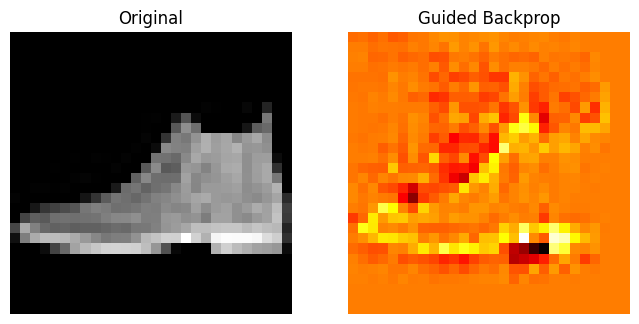

In [11]:

# ==========================================
# 1. Import Libraries
# ==========================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

# ==========================================
# 2. Load Dataset
# ==========================================
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# Add channel dimension
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# Use subset (fast ⚡)
X_train = X_train[:10000]
y_train = y_train[:10000]

# ==========================================
# 3. Build CNN Model
# ==========================================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPool2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPool2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(X_train, y_train, epochs=3, batch_size=32)

# ==========================================
# 4. Guided ReLU (IMPORTANT FIX 🔥)
# ==========================================
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32") * dy
    return tf.nn.relu(x), grad

# Replace activations
for layer in model.layers:
    if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
        layer.activation = guided_relu

# ==========================================
# 5. Select Image
# ==========================================
img = X_test[0]
img = np.expand_dims(img, axis=0)

# ==========================================
# 6. Compute Gradients
# ==========================================
input_tensor = tf.convert_to_tensor(img)

with tf.GradientTape() as tape:
    tape.watch(input_tensor)
    predictions = model(input_tensor)

    class_idx = tf.argmax(predictions[0])
    loss = predictions[:, class_idx]

grads = tape.gradient(loss, input_tensor)[0]

# Normalize gradients
grads = (grads - tf.reduce_min(grads)) / (tf.reduce_max(grads) - tf.reduce_min(grads))

# ==========================================
# 7. Visualization
# ==========================================
plt.figure(figsize=(8,4))

# Original image
plt.subplot(1,2,1)
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title("Original")
plt.axis('off')

# Guided Backprop
plt.subplot(1,2,2)
plt.imshow(grads.numpy().reshape(28,28), cmap='hot')
plt.title("Guided Backprop")
plt.axis('off')

plt.show()



#Auto Encoder

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.4147 - val_loss: 0.3453
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3294 - val_loss: 0.3210
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3126 - val_loss: 0.3092
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3029 - val_loss: 0.3012
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2962 - val_loss: 0.2957
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2918 - val_loss: 0.2923
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2890 - val_loss: 0.2902
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2874 - val_loss: 0.2889
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2863 - val_loss: 0.2881
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2856 - val_loss: 0.2875
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2851 - val_loss: 0.2870
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

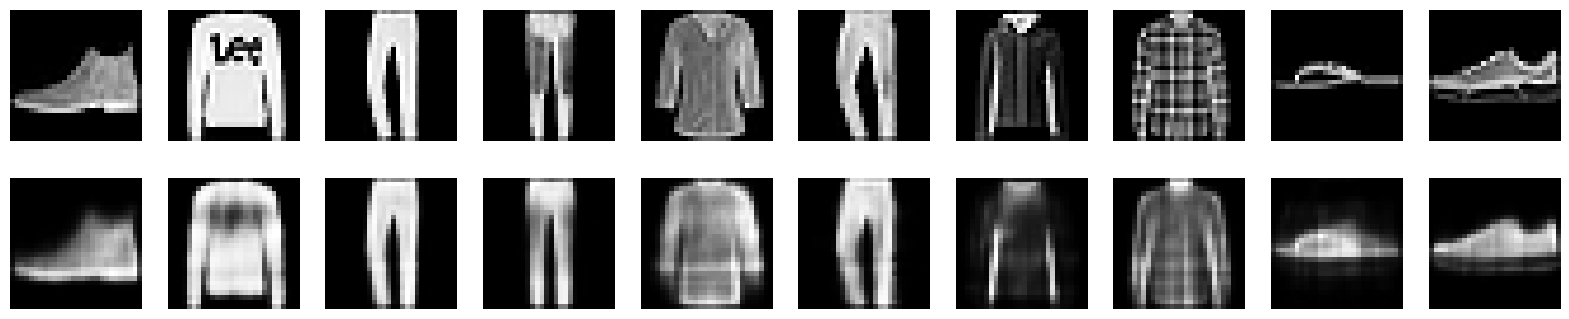

In [12]:

# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# ==========================================
# 2. Load and Prepare Data
# ==========================================
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize (0–255 → 0–1)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape (2D → 1D vector)
# 60000 x 28 x 28 → 60000 x 784
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# ==========================================
# 3. Define Encoder and Decoder
# ==========================================
input_dim = 784
encoding_dim = 32   # 🔥 Try: 16, 32, 64, 128

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# ==========================================
# 4. Create Model
# ==========================================
autoencoder = Model(input_layer, decoded)

# ==========================================
# 5. Compile
# ==========================================
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# ==========================================
# 6. Train
# ==========================================
autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# ==========================================
# 7. Test
# ==========================================
decoded_imgs = autoencoder.predict(x_test)

# ==========================================
# 8. Visualize
# ==========================================
n = 10
plt.figure(figsize=(20,4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray()
    ax.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28))
    plt.gray()
    ax.axis('off')

plt.show()



The autoencoder shows a steady decrease in training loss from 0.4147 to 0.2832, indicating effective learning. The validation loss closely follows the training loss, suggesting good generalization without overfitting. Most of the improvement occurs in the initial epochs, with rapid reduction in loss up to around epoch 5. After epoch 10, the loss stabilizes, indicating convergence of the model. The minimal gap between training and validation loss reflects stable and consistent training. Further training beyond epoch 12 results in only marginal improvements. Overall, the model successfully learns compact representations while preserving essential input features.

In [13]:


# ==========================================
# COMMON DATA LOADING (RUN THIS FIRST)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist

# Load dataset
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten for Dense AE
x_train_flat = x_train.reshape((len(x_train), 784))
x_test_flat = x_test.reshape((len(x_test), 784))

# Reshape for CNN AE
x_train_cnn = x_train.reshape((len(x_train), 28, 28, 1))
x_test_cnn = x_test.reshape((len(x_test), 28, 28, 1))



# ==========================================
# 2. Define Undercomplete AE
# ==========================================

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_layer = Input(shape=(784,))
encoded = Dense(32, activation='relu')(input_layer)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train_flat, x_train_flat, epochs=20, batch_size=256)

decoded_imgs = autoencoder.predict(x_test_flat)




Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.4130
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3274
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3104
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3013
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2953
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2913
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.2888
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2873
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2863
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2855
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2850
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2846
Epoch 13/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2842
Epoch 14/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2839
Epoch 15/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/st

In [14]:
#over complete
input_layer = Input(shape=(784,))
encoded = Dense(1024, activation='relu')(input_layer)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train_flat, x_train_flat, epochs=20, batch_size=256)

decoded_imgs = autoencoder.predict(x_test_flat)



Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - loss: 0.3214
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - loss: 0.2727
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - loss: 0.2641
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - loss: 0.2601
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.2574
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.2557
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.2542
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.2531
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - loss: 0.2521
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - loss: 0.2513
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - loss: 0.2508
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - loss: 0.2503
Epoch 13/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.2496
Epoch 14/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - loss: 0.2493
Epoch 15/20
235/235 ━━━━━━━━━

The undercomplete autoencoder shows a steady reduction in loss from 0.4130 to 0.2830, indicating that it learns compact and meaningful representations by compressing the input data. The improvement is rapid in the initial epochs and stabilizes after around epoch 10, showing convergence. Due to its limited latent space, it focuses only on essential features and avoids memorization.

In contrast, the overcomplete autoencoder achieves a lower final loss of 0.2476, indicating better reconstruction capability. The larger hidden layer allows the model to retain more information, resulting in sharper and more accurate outputs. However, this also increases the risk of the model learning identity mapping instead of meaningful feature extraction.

Overall, the undercomplete autoencoder provides better feature compression and generalization, while the overcomplete autoencoder achieves superior reconstruction at the cost of potential overfitting.


In [ ]:
#denoising
import keras
from keras import layers

# Add noise
noise_factor = 0.3
x_train_noisy = x_train_cnn + noise_factor * np.random.normal(size=x_train_cnn.shape)
x_test_noisy = x_test_cnn + noise_factor * np.random.normal(size=x_test_cnn.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Model
input_img = keras.Input(shape=(28,28,1))

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2,2), padding='same')(x)
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)

decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train_noisy, x_train_cnn, epochs=15, batch_size=36)

decoded_imgs = autoencoder.predict(x_test_noisy)


Epoch 1/15
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 146s 86ms/step - loss: 0.2951
Epoch 2/15
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 185s 76ms/step - loss: 0.2790
Epoch 3/15
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 126s 76ms/step - loss: 0.2755
Epoch 4/15
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 125s 75ms/step - loss: 0.2739
Epoch 5/15
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 141s 75ms/step - loss: 0.2729
Epoch 6/15
 404/1667 ━━━━━━━━━━━━━━━━━━━━ 1:32 74ms/step - loss: 0.2709

In [ ]:
import matplotlib.pyplot as plt

n = 10  # number of images to display

plt.figure(figsize=(20, 6))

for i in range(n):
    # Noisy images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

    # Original images
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test_cnn[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

plt.show()

In [17]:

from sklearn.decomposition import PCA

# PCA
pca = PCA(n_components=32)
x_train_pca = pca.fit_transform(x_train_flat)
x_test_pca = pca.transform(x_test_flat)
x_test_pca_reconstructed = pca.inverse_transform(x_test_pca)

# Autoencoder
input_layer = Input(shape=(784,))
encoded = Dense(32, activation='relu')(input_layer)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train_flat, x_train_flat, epochs=10, batch_size=256)

decoded_imgs = autoencoder.predict(x_test_flat)


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.4145
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.3265
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3107
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3012
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2951
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2913
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2890
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2874
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2864
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2856
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(20, 8))

for i in range(n):

    # Original
    ax = plt.subplot(4, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # PCA Reconstruction
    ax = plt.subplot(4, n, i + 1 + n)
    plt.imshow(x_test_pca_reconstructed[i].reshape(28, 28), cmap='gray')
    plt.title("PCA")
    plt.axis("off")

    # Autoencoder Reconstruction
    ax = plt.subplot(4, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Autoencoder")
    plt.axis("off")

plt.show()

In [18]:
#sparse


input_layer = Input(shape=(784,))
encoded = Dense(32, activation='relu',
                activity_regularizer=regularizers.l1(1e-4))(input_layer)

decoded = Dense(784, activation='sigmoid')(encoded)

sparse_ae = Model(input_layer, decoded)
sparse_ae.compile(optimizer='adam', loss='binary_crossentropy')

sparse_ae.fit(x_train_flat, x_train_flat, epochs=20, batch_size=256)

decoded_imgs = sparse_ae.predict(x_test_flat)





Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.6704
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.6284
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.5988
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.5764
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5592
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5459
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5355
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5273
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.5208
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5156
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5113
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5079
Epoch 13/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5051
Epoch 14/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.5027
Epoch 15/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/st

In [ ]:
from tensorflow.keras import regularizers

input_layer = Input(shape=(784,))
encoded = Dense(32, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_layer)
decoded = Dense(784, activation='sigmoid')(encoded)

sparse_autoencoder = Model(input_layer, decoded)
sparse_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

sparse_autoencoder.fit(x_train_flat, x_train_flat, epochs=10, batch_size=256)

decoded_sparse = sparse_autoencoder.predict(x_test_flat)